# Deepfake Classifier — Evaluation
Compares the **original** `facebook/dinov2-base` landmark model against the
**fine-tuned** version (loaded from `./fine_tuned_model_delta/weight_delta.pt`)
on the test split of `zguo0525/google-landmarks-v2-mini`.

Additionally, runs the full integrated `DeepfakeClassifier` pipeline on a
sample image to validate the end-to-end workflow.

> ⚠️ **Pre-requisite:** Run `deepfake_classifier_finetuning.ipynb` first to train
> the model and generate `./fine_tuned_model_delta/weight_delta.pt`.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from deepfake_classifier import DeepfakeClassifier, compute_metrics

W0508 13:24:37.134000 54063 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


## 1. Load the Landmark Test Dataset

In [2]:
dataset = load_dataset('zguo0525/google-landmarks-v2-mini')
test_dataset = dataset['test']
label_names = dataset['train'].features['label'].names
num_classes = len(label_names)
print(f"Loaded {len(test_dataset)} test examples across {num_classes} landmark classes.")

Loaded 6206 test examples across 3103 landmark classes.


## 2. Load Both Landmark Models
We load the original DINOv2 base model (un-fine-tuned) and the fine-tuned
checkpoint (via weight delta) to compare their landmark classification accuracy.

In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')

print("Loading original DINOv2 base model...")
original_model = AutoModelForImageClassification.from_pretrained(
    'facebook/dinov2-base',
    num_labels=num_classes,
    id2label={str(i): name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
    ignore_mismatched_sizes=True
).to(device)
original_model.eval()
print("Original model ready.")

Using device: mps
Loading original DINOv2 base model...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[transformers] Dinov2ForImageClassification LOAD REPORT from: facebook/dinov2-base
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Original model ready.


In [4]:
import os

# Prefer delta-based loading (same pattern as visual module)
delta_path = './fine_tuned_model_delta/weight_delta.pt'
full_model_path = './fine_tuned_model'

if os.path.exists(delta_path):
    print("Loading fine-tuned DINOv2 landmark model from weight delta...")
    from deepfake_classifier import load_weight_delta
    fine_tuned_model = AutoModelForImageClassification.from_pretrained(
        'facebook/dinov2-base',
        num_labels=num_classes,
        id2label={str(i): name for i, name in enumerate(label_names)},
        label2id={name: i for i, name in enumerate(label_names)},
        ignore_mismatched_sizes=True
    ).to(device)
    load_weight_delta(fine_tuned_model, delta_path, device=device)
    print("Delta applied successfully.")
elif os.path.exists(full_model_path):
    print("Loading fine-tuned DINOv2 landmark model from full checkpoint...")
    fine_tuned_model = AutoModelForImageClassification.from_pretrained(full_model_path).to(device)
else:
    raise FileNotFoundError(
        f"Neither '{delta_path}' nor '{full_model_path}' found. "
        "Run deepfake_classifier_finetuning.ipynb first."
    )

fine_tuned_model.eval()
print("Fine-tuned model ready.")

Loading fine-tuned DINOv2 landmark model from full checkpoint...


Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Fine-tuned model ready.


## 3. Quick Sanity Check — Single Sample

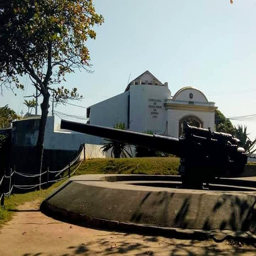

Ground Truth: 0
Original model  : 1283 (confidence: 0.0064)
Fine-tuned model: 875 (confidence: 0.0012)


In [5]:
from IPython.display import display

sample = test_dataset[0]
sample_image = sample['image'].convert('RGB')
sample_label = label_names[sample['label']]

display(sample_image.resize((256, 256)))
print(f"Ground Truth: {sample_label}")

def predict_single(model, image):
    inputs = processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    idx = logits.argmax(-1).item()
    conf = torch.softmax(logits, dim=-1)[0, idx].item()
    return label_names[idx], round(conf, 4)

orig_label, orig_conf = predict_single(original_model, sample_image)
ft_label, ft_conf     = predict_single(fine_tuned_model, sample_image)

print(f"Original model  : {orig_label} (confidence: {orig_conf})")
print(f"Fine-tuned model: {ft_label} (confidence: {ft_conf})")

## 4. Full Test-Set Evaluation
Runs inference for both models across the entire test split.

> 💡 For a quick smoke-test, uncomment `num_samples = 200`.

In [6]:
num_samples = len(test_dataset)
# num_samples = 200  # uncomment for a quick test

orig_true, orig_pred = [], []
ft_true,   ft_pred   = [], []

for i in tqdm(range(num_samples), desc="Evaluating both models"):
    item = test_dataset[i]
    img  = item['image'].convert('RGB')
    true = label_names[item['label']]

    orig_lbl, _ = predict_single(original_model, img)
    ft_lbl,   _ = predict_single(fine_tuned_model, img)

    orig_true.append(true); orig_pred.append(orig_lbl)
    ft_true.append(true);   ft_pred.append(ft_lbl)

print("Evaluation complete.")

Evaluating both models:   0%|          | 0/6206 [00:00<?, ?it/s]

Evaluation complete.


## 5. Results — Original Model

In [7]:
print("=== Original DINOv2 (un-fine-tuned) ===")
print("\nClassification Report:")
print(classification_report(orig_true, orig_pred, zero_division=0))

=== Original DINOv2 (un-fine-tuned) ===

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         2
         100       0.00      0.00      0.00         2
        1000       0.00      0.00      0.00         2
        1001       0.00      0.00      0.00         2
        1002       0.00      0.00      0.00         2
        1003       0.00      0.00      0.00         2
        1004       0.00      0.00      0.00         2
        1005       0.00      0.00      0.00         2
        1006       0.00      0.00      0.00         2
        1007       0.00      0.00      0.00         2
        1008       0.00      0.00      0.00         2
        1009       0.00      0.00      0.00         2
         101       0.00      0.00      0.00         2
        1010       0.00      0.00      0.00         2
        1011     

## 6. Results — Fine-Tuned Model

In [8]:
print("=== Fine-Tuned DINOv2 Landmark Model ===")
print("\nClassification Report:")
print(classification_report(ft_true, ft_pred, zero_division=0))

=== Fine-Tuned DINOv2 Landmark Model ===

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         2
         100       0.00      0.00      0.00         2
        1000       0.00      0.00      0.00         2
        1001       0.00      0.00      0.00         2
        1002       0.00      0.00      0.00         2
        1003       0.00      0.00      0.00         2
        1004       0.00      0.00      0.00         2
        1005       0.00      0.00      0.00         2
        1006       0.00      0.00      0.00         2
        1007       0.00      0.00      0.00         2
        1008       0.00      0.00      0.00         2
        1009       0.00      0.00      0.00         2
         101       0.00      0.00      0.00         2
        1010       0.00      0.00      0.00         2
        1011    

## 7. Side-by-Side Accuracy Comparison

In [9]:
orig_acc = accuracy_score(orig_true, orig_pred)
ft_acc   = accuracy_score(ft_true,   ft_pred)

print(f"Original model accuracy  : {orig_acc:.4f} ({orig_acc*100:.2f}%)")
print(f"Fine-tuned model accuracy: {ft_acc:.4f} ({ft_acc*100:.2f}%)")
print(f"Improvement              : {(ft_acc - orig_acc)*100:+.2f} pp")

Original model accuracy  : 0.0005 (0.05%)
Fine-tuned model accuracy: 0.0029 (0.29%)
Improvement              : +0.24 pp


## 8. Integrated `DeepfakeClassifier` — End-to-End Test
Instantiates the full `DeepfakeClassifier` (face + scene + fine-tuned landmark)
and runs it on a single test image to validate the complete pipeline.

Uses the weight-delta loading path when the delta file is available.

In [10]:
print("Initialising DeepfakeClassifier with the fine-tuned landmark model...")

if os.path.exists(delta_path):
    deepfake_classifier = DeepfakeClassifier(
        landmark_model_path=None,
        landmark_delta_path=delta_path,
    )
else:
    deepfake_classifier = DeepfakeClassifier(
        landmark_model_path="./fine_tuned_model",
    )

print("DeepfakeClassifier ready.")

Initialising DeepfakeClassifier with the fine-tuned landmark model...
Loading Face Forensics model: prithivMLmods/deepfake-detector-model-v1


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[08/May/2026 13:34:55.0970 INFO fs_ops.py:1163] Creating models directory...


Loading Scene model: birder-project/rope_vit_reg4_b14_capi-places365


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading fine-tuned Landmark model from: ./fine_tuned_model


Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

DeepfakeClassifier ready.


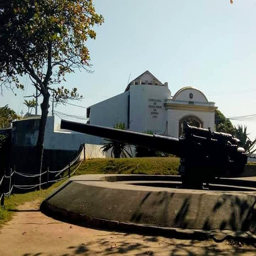


=== Deepfake Classifier Results ===
Final Decision          : Potential Deepfake
Deepfake Confidence     : 0.6986
Face Analysis           : {'label': 'Fake', 'confidence': 0.6986, 'probs': [0.6986422538757324, 0.3013577163219452]}
Scene Analysis          : {'label': 'cannon', 'confidence': 0.9771}
Landmark Analysis       : {'label': '875', 'confidence': 0.0012}


In [11]:
sample_image = test_dataset[0]['image'].convert('RGB')
display(sample_image.resize((256, 256)))

# Run without the visual classifier gate (will always run all sub-models)
results = deepfake_classifier.predict(sample_image)

print("\n=== Deepfake Classifier Results ===")
print(f"Final Decision          : {results['final_decision']}")
if results['deepfake_analysis']:
    da = results['deepfake_analysis']
    print(f"Deepfake Confidence     : {da['deepfake_confidence']}")
    print(f"Face Analysis           : {da['face_analysis']}")
    print(f"Scene Analysis          : {da['scene_analysis']}")
    print(f"Landmark Analysis       : {da['landmark_analysis']}")